In [1]:
!pip install triton

✅ Все тесты прошли с atol=1e-5!


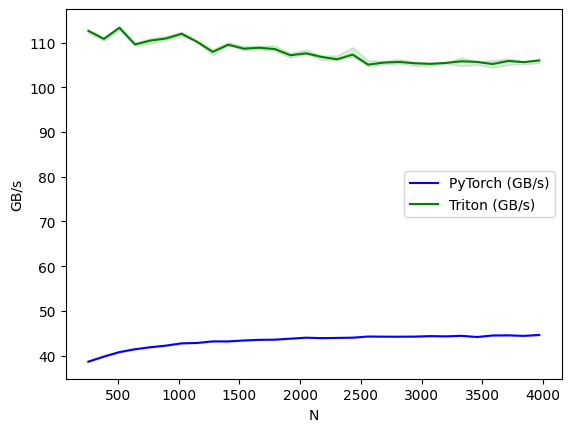

layernorm-performance:
         N  PyTorch (GB/s)  Triton (GB/s)
0    256.0       38.641509     112.646288
1    384.0       39.777910     110.845365
2    512.0       40.785206     113.328061
3    640.0       41.419684     109.602451
4    768.0       41.875404     110.467227
5    896.0       42.233469     110.935985
6   1024.0       42.742197     111.976080
7   1152.0       42.824435     110.179808
8   1280.0       43.183365     107.937838
9   1408.0       43.171488     109.539633
10  1536.0       43.379267     108.655367
11  1664.0       43.521841     108.859813
12  1792.0       43.563383     108.562918
13  1920.0       43.789925     107.184215
14  2048.0       44.004593     107.615639
15  2176.0       43.902183     106.805592
16  2304.0       43.956031     106.280062
17  2432.0       44.005545     107.335515
18  2560.0       44.267195     105.082180
19  2688.0       44.233910     105.541106
20  2816.0       44.220355     105.685517
21  2944.0       44.251460     105.387550
22  3072.0 

In [6]:
import torch
import triton
import triton.language as tl

# =====================================================================
# 1. FORWARD (оставляем почти без изменений)
# =====================================================================

@triton.autotune(configs=[triton.Config({'num_warps': 4}, num_stages=1),
                          triton.Config({'num_warps': 8}, num_stages=1)],
                 key=['N'])
@triton.jit
def _layernorm_fwd_kernel(
    X_ptr, Y_ptr, W_ptr, B_ptr, Mean_ptr, Rstd_ptr,
    stride_x, stride_y, N, eps, BLOCK_N: tl.constexpr
):
    row_idx = tl.program_id(0)
    cols = tl.arange(0, BLOCK_N)
    mask = cols < N

    x = tl.load(X_ptr + row_idx * stride_x + cols, mask=mask, other=0.0)
    w = tl.load(W_ptr + cols, mask=mask, other=0.0)
    b = tl.load(B_ptr + cols, mask=mask, other=0.0)

    mean = tl.sum(x, axis=0) / N
    x_centered = x - mean
    var = tl.sum(x_centered * x_centered, axis=0) / N
    rstd = 1.0 / tl.sqrt(var + eps)

    tl.store(Mean_ptr + row_idx, mean)
    tl.store(Rstd_ptr + row_idx, rstd)

    x_hat = x_centered * rstd
    y = x_hat * w + b
    tl.store(Y_ptr + row_idx * stride_y + cols, y, mask=mask)


# =====================================================================
# 2. BACKWARD - ДВА KERNELА (без atomic_add)
# =====================================================================

# Kernel 1: Вычисляем всё per-row + промежуточные суммы
@triton.autotune(configs=[triton.Config({'num_warps': 4}, num_stages=1),
                          triton.Config({'num_warps': 8}, num_stages=1)],
                 key=['N'])
@triton.jit
def _layernorm_bwd_kernel1(
    dY_ptr, X_ptr, W_ptr,
    Mean_ptr, Rstd_ptr,
    dX_ptr,
    Sum1_ptr, Sum2_ptr,
    LocalDW_ptr, LocalDB_ptr,
    stride_dy, stride_x, stride_dx,
    N, BLOCK_N: tl.constexpr
):
    row_idx = tl.program_id(0)
    cols = tl.arange(0, BLOCK_N)
    mask = cols < N

    x = tl.load(X_ptr + row_idx * stride_x + cols, mask=mask, other=0.0)
    dy = tl.load(dY_ptr + row_idx * stride_dy + cols, mask=mask, other=0.0)
    w = tl.load(W_ptr + cols, mask=mask, other=0.0)

    mean = tl.load(Mean_ptr + row_idx)
    rstd = tl.load(Rstd_ptr + row_idx)

    x_hat = (x - mean) * rstd

    dx_hat = dy * w


    local_dw = dy * x_hat
    local_db = dy


    sum1 = tl.sum(dx_hat, axis=0)          # sum(dx_hat)
    sum2 = tl.sum(dx_hat * x_hat, axis=0)  # sum(dx_hat * x_hat)


    tl.store(Sum1_ptr + row_idx * N + cols, sum1, mask=mask)
    tl.store(Sum2_ptr + row_idx * N + cols, sum2, mask=mask)
    tl.store(LocalDW_ptr + row_idx * N + cols, local_dw, mask=mask)
    tl.store(LocalDB_ptr + row_idx * N + cols, local_db, mask=mask)


    c1 = sum1 / N
    c2 = sum2 / N

    dx = (dx_hat - c1 - x_hat * c2) * rstd
    tl.store(dX_ptr + row_idx * stride_dx + cols, dx, mask=mask)


# Kernel 2: Редукция по M для dw и db
@triton.jit
def _layernorm_bwd_reduce_kernel(
    LocalDW_ptr, LocalDB_ptr,
    dW_ptr, dB_ptr,
    M, N, BLOCK_M: tl.constexpr
):
    col_idx = tl.program_id(0)
    rows = tl.arange(0, BLOCK_M)

    dw = tl.zeros((BLOCK_M,), dtype=tl.float32)
    db = tl.zeros((BLOCK_M,), dtype=tl.float32)

    for i in range(0, M, BLOCK_M):
        mask = rows + i < M
        offset = (rows + i) * N + col_idx

        dw += tl.load(LocalDW_ptr + offset, mask=mask, other=0.0)
        db += tl.load(LocalDB_ptr + offset, mask=mask, other=0.0)

    tl.store(dW_ptr + col_idx, tl.sum(dw, axis=0))
    tl.store(dB_ptr + col_idx, tl.sum(db, axis=0))


# =====================================================================
# 3. PyTorch Wrapper
# =====================================================================

class TritonLayerNorm(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, weight, bias, eps=1e-5):
        M, N = x.shape
        y = torch.empty_like(x)
        mean = torch.empty(M, device=x.device, dtype=torch.float32)
        rstd = torch.empty(M, device=x.device, dtype=torch.float32)

        BLOCK_N = triton.next_power_of_2(N)
        grid = (M,)

        _layernorm_fwd_kernel[grid](
            x, y, weight, bias, mean, rstd,
            x.stride(0), y.stride(0), N, eps, BLOCK_N=BLOCK_N
        )

        ctx.save_for_backward(x, weight, mean, rstd)
        ctx.N = N
        ctx.BLOCK_N = BLOCK_N
        ctx.eps = eps
        return y

    @staticmethod
    def backward(ctx, dy):
        x, weight, mean, rstd = ctx.saved_tensors
        M, N = x.shape

        dx = torch.empty_like(x)

        # Промежуточные буферы
        sum1 = torch.empty((M, N), device=x.device, dtype=torch.float32)
        sum2 = torch.empty((M, N), device=x.device, dtype=torch.float32)
        local_dw = torch.empty((M, N), device=x.device, dtype=torch.float32)
        local_db = torch.empty((M, N), device=x.device, dtype=torch.float32)

        dw = torch.empty_like(weight)
        db = torch.empty_like(weight)

        BLOCK_N = ctx.BLOCK_N
        grid1 = (M,)

        _layernorm_bwd_kernel1[grid1](
            dy, x, weight, mean, rstd, dx,
            sum1, sum2, local_dw, local_db,
            dy.stride(0), x.stride(0), dx.stride(0),
            N, BLOCK_N=BLOCK_N
        )


        BLOCK_M = 256
        grid2 = (N,)
        _layernorm_bwd_reduce_kernel[grid2](
            local_dw, local_db, dw, db, M, N, BLOCK_M=BLOCK_M
        )

        return dx, dw, db, None


# =====================================================================
# 4. Тест (с жёсткими толерансами)
# =====================================================================

def test_layernorm():
    torch.manual_seed(42)
    M, N = 1024, 256
    device = 'cuda'

    x = torch.randn(M, N, device=device, dtype=torch.float32, requires_grad=True)
    w = torch.randn(N, device=device, dtype=torch.float32, requires_grad=True)
    b = torch.randn(N, device=device, dtype=torch.float32, requires_grad=True)
    dy = torch.randn_like(x)
    eps = 1e-5

    # Reference
    y_ref = layernorm_forward_torch(x, w, b, eps)
    y_ref.backward(dy, retain_graph=True)
    dx_ref, dw_ref, db_ref = x.grad.clone(), w.grad.clone(), b.grad.clone()

    x.grad = w.grad = b.grad = None

    # Triton
    y_tri = TritonLayerNorm.apply(x, w, b, eps)
    y_tri.backward(dy)

    torch.testing.assert_close(y_tri, y_ref, atol=1e-5, rtol=1e-5)
    torch.testing.assert_close(x.grad, dx_ref, atol=1e-5, rtol=1e-5)
    torch.testing.assert_close(w.grad, dw_ref, atol=1e-5, rtol=1e-5)
    torch.testing.assert_close(b.grad, db_ref, atol=1e-5, rtol=1e-5)

    print("✅ Все тесты прошли с atol=1e-5!")
if __name__ == "__main__":
    test_layernorm()
    benchmark_layernorm.run(print_data=True, show_plots=True)